In [1]:
# Cell 1 - Install libraries
!pip install matplotlib seaborn scikit-learn pandas openpyxl -q

In [2]:
# Install missing library
!pip install seaborn -q

In [3]:
# Cell 2 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [4]:
import seaborn as sns

In [14]:
# Cell 3 - Load the dataset
df = pd.read_csv("bank-full.csv", sep=";")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (45211, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [15]:
df.shape

(45211, 17)

In [16]:
print("=== Missing Values ===")
print(df.isnull().sum())

print(f"\n=== Duplicate Rows ===")
print(f"Duplicates: {df.duplicated().sum()}")

print(f"\n=== Basic Statistics ===")
df.describe()

=== Missing Values ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

=== Duplicate Rows ===
Duplicates: 0

=== Basic Statistics ===


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [17]:
# Replace 'unknown' with NaN and drop
df.replace("unknown", np.nan, inplace=True)
print(f"Missing after replacing 'unknown': \n{df.isnull().sum()}")

# Drop rows with missing values (only ~5% of data)
df.dropna(inplace=True)
print(f"\n✅ Clean dataset shape: {df.shape}")

Missing after replacing 'unknown': 
age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64

✅ Clean dataset shape: (7842, 17)


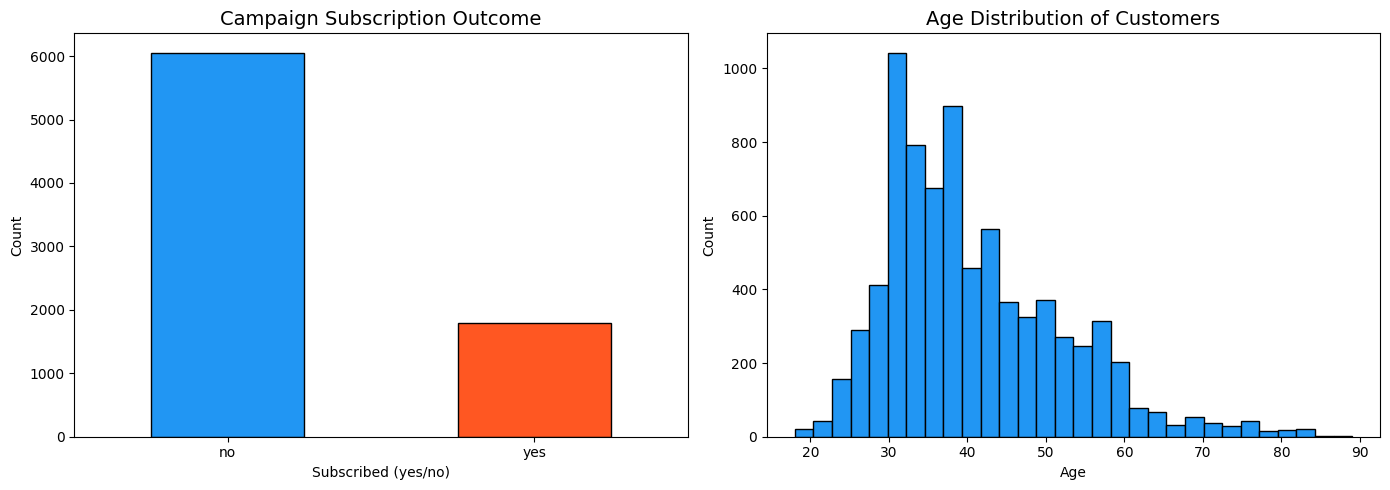

✅ Chart saved!


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subscription rate
df['y'].value_counts().plot(kind='bar', ax=axes[0], 
                             color=['#2196F3','#FF5722'], edgecolor='black')
axes[0].set_title('Campaign Subscription Outcome', fontsize=14)
axes[0].set_xlabel('Subscribed (yes/no)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Age distribution
axes[1].hist(df['age'], bins=30, color='#2196F3', edgecolor='black')
axes[1].set_title('Age Distribution of Customers', fontsize=14)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
save_path = '/home/azureuser/cloudfiles/code/Users/aazartaheri/'
plt.savefig(f'{save_path}campaign_overview.png', dpi=150, bbox_inches='tight')
 
plt.show()
print("✅ Chart saved!")

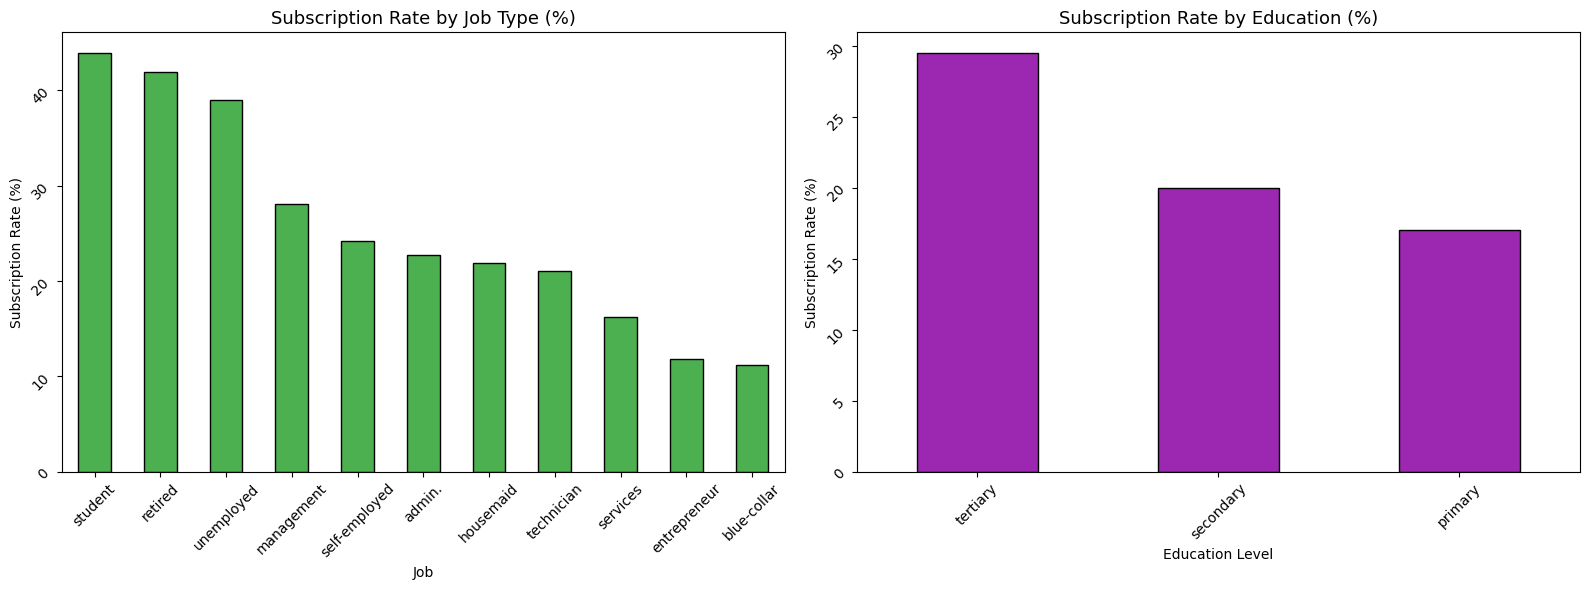

✅ Chart saved!


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subscription by job
job_sub = df.groupby('job')['y'].apply(
    lambda x: (x=='yes').sum()/len(x)*100).sort_values(ascending=False)
job_sub.plot(kind='bar', ax=axes[0], color='#4CAF50', edgecolor='black')
axes[0].set_title('Subscription Rate by Job Type (%)', fontsize=13)
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].tick_params(rotation=45)

# Subscription by education
edu_sub = df.groupby('education')['y'].apply(
    lambda x: (x=='yes').sum()/len(x)*100).sort_values(ascending=False)
edu_sub.plot(kind='bar', ax=axes[1], color='#9C27B0', edgecolor='black')
axes[1].set_title('Subscription Rate by Education (%)', fontsize=13)
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].tick_params(rotation=45)

plt.tight_layout()
plt.savefig('subscription_by_segment.png', dpi=150)
plt.show()
print("✅ Chart saved!")

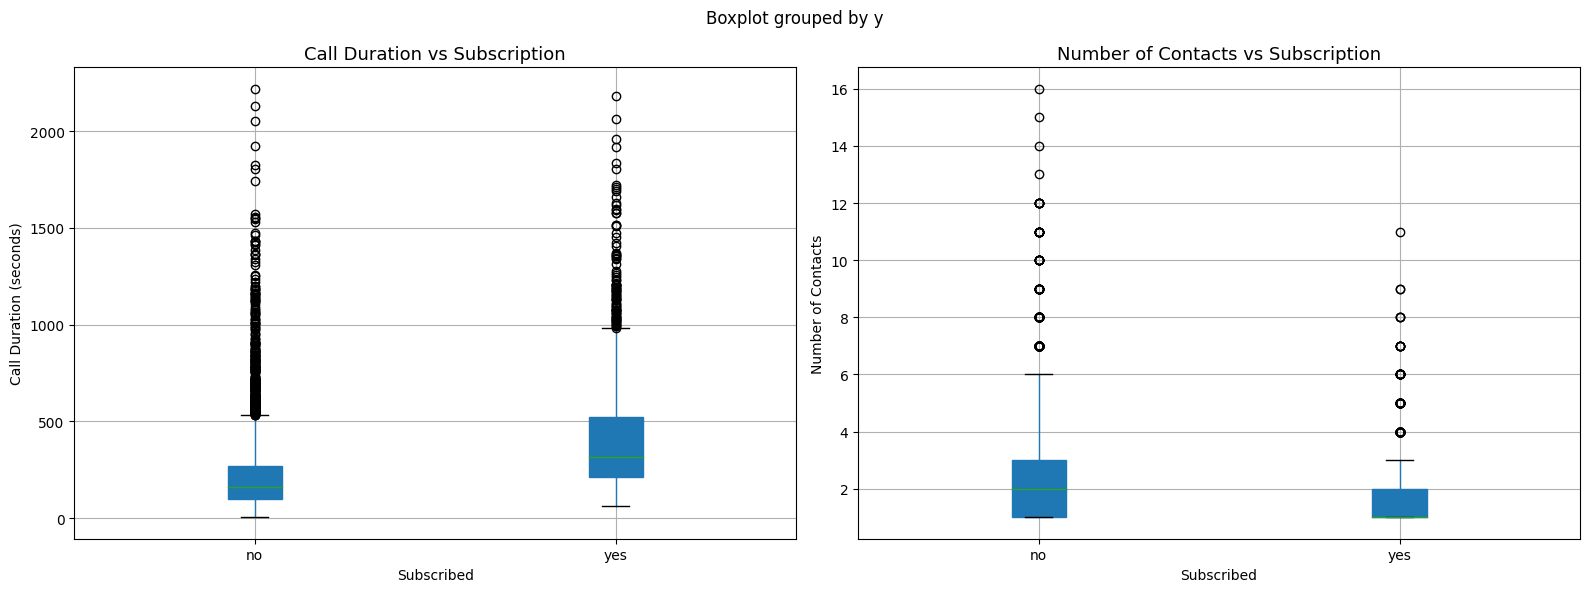

✅ Chart saved!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contact duration vs subscription
df.boxplot(column='duration', by='y', ax=axes[0], 
           patch_artist=True)
axes[0].set_title('Call Duration vs Subscription', fontsize=13)
axes[0].set_xlabel('Subscribed')
axes[0].set_ylabel('Call Duration (seconds)')

# Number of contacts
df.boxplot(column='campaign', by='y', ax=axes[1],
           patch_artist=True)
axes[1].set_title('Number of Contacts vs Subscription', fontsize=13)
axes[1].set_xlabel('Subscribed')
axes[1].set_ylabel('Number of Contacts')

plt.tight_layout()
plt.savefig('campaign_analysis.png', dpi=150)
plt.show()
print("✅ Chart saved!")

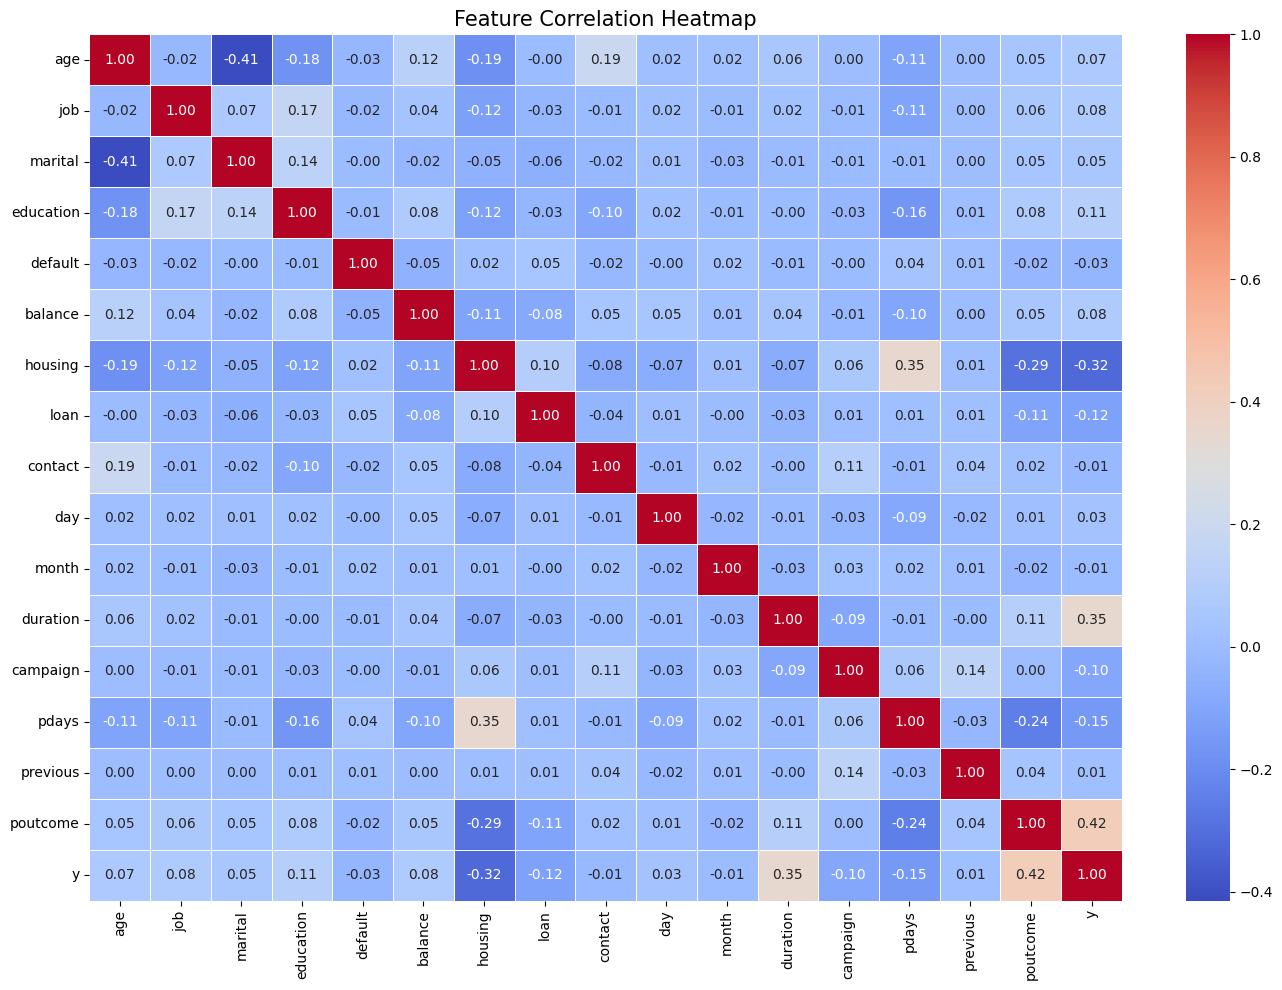

✅ Heatmap saved!


In [21]:
# Encode categorical columns for correlation
df_encoded = df.copy()
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include='object').columns
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", 
            cmap="coolwarm", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap saved!")

In [22]:
# Save cleaned data for next notebooks
df.to_csv('bank_clean.csv', index=False)
df_encoded.to_csv('bank_encoded.csv', index=False)
print(f"✅ Clean dataset saved!")
print(f"Final shape: {df.shape}")
print(f"\nKey insight: {round((df['y']=='yes').sum()/len(df)*100, 1)}% of customers subscribed")

✅ Clean dataset saved!
Final shape: (7842, 17)

Key insight: 22.8% of customers subscribed


In [23]:
import os
print("Current working directory:", os.getcwd())
print("\nFiles in current directory:")
for f in os.listdir('.'):
    print(f)

Current working directory: /mnt/batch/tasks/shared/LS_root/mounts/clusters/ml-compute/code/Users/aazartaheri

Files in current directory:
.amlignore
.amlignore.amltmp
.ipynb_aml_checkpoints
01_data_cleaning_EDA.ipynb
01_data_cleaning_eda.ipynb.amltmp
bank-full.csv
bank_clean.csv
bank_encoded.csv
campaign_analysis.png
campaign_overview.png
correlation_heatmap.png
subscription_by_segment.png


In [24]:
# Re-save all charts to the correct path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Check if any PNGs exist anywhere
for root, dirs, files in os.walk('/home'):
    for file in files:
        if file.endswith('.png'):
            print(os.path.join(root, file))